## Human In the Loop

In [2]:
!pip install langgraph langchain langchain-core langchain-community langchain-tavily langchain-groq typing-extensions tavily-python

In [ ]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.types import Command, interrupt
import os
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage


os.environ["GROQ_API_KEY"] = ""
os.environ["TAVILY_API_KEY"] =""
llm=init_chat_model("groq:llama-3.1-8b-instant")
# print(llm)

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

# tools
tavily_tool = TavilySearch(max_results=2)


# interrupt is graph level pause 
@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human."""
    human_response = interrupt({"query": query})
    return human_response["data"]


tools = [tavily_tool,human_assistance]


llm_with_tools = llm.bind_tools(
    tools,
    tool_choice="auto"
)

def policy_router(state: State):
    user_msg = state["messages"][-1].content.lower()
    policy_keywords = [
        "policy",
        "leave policy",
        "hr policy",
        "company rule",
        "vacation policy",
        "security policy",
        "compliance",
        "work from home policy"
    ]
    if any(word in user_msg for word in policy_keywords):
        return Command(goto="human_policy")
    return Command(goto="chatbot")


def chatbot(state: State):
    message = llm_with_tools.invoke(state["messages"])
    return {"messages": [message]}

def human_policy(state: State):
    query = state["messages"][-1].content
    human_response = interrupt({"query": query})
    return {
        "messages": [HumanMessage(content=human_response["data"])]
    }

def format_policy_answer(state: State):
    human_answer = state["messages"][-1].content
    prompt = f"""
        You are an assistant helping structure company policy answers.
        Rewrite the following human answer clearly:
        - Correct grammar
        - Improve clarity
        - Improve clarity
        - Make it professional

        Human answer: {human_answer}
    """

    response = llm.invoke(prompt)

    return {"messages": [response]}



# nodes 

graph_builder.add_node("policy_router", policy_router)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("human_policy", human_policy)
graph_builder.add_node("format_policy_answer", format_policy_answer)
tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)




# edges
graph_builder.add_edge(START, "policy_router")
graph_builder.add_edge("human_policy", "format_policy_answer")
graph_builder.add_edge("format_policy_answer", END)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition
)
graph_builder.add_edge("tools", "chatbot")

/Users/anideepkalia/Documents/ML-tut/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

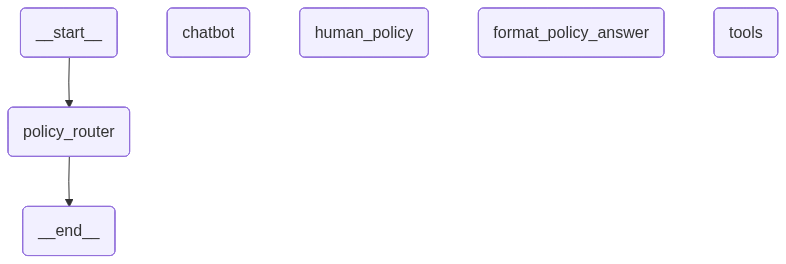

In [5]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [6]:
# user_input = "What is the latest news on AI?"
# user_input = input("Your question: ")

config = {"configurable": {"thread_id": "1"}}

while True:

    user_input = input("\nYour question: ")

    events = graph.stream(
        {"messages": user_input},
        config,
        stream_mode="values",
    )

    for event in events:
        if "messages" in event:
            event["messages"][-1].pretty_print()

    state = graph.get_state(config)

    # Human interruption logic
    if state.tasks and state.tasks[0].interrupts:

        interrupt_data = state.tasks[0].interrupts[0].value

        print("\nAgent needs human help:")
        print("Question:", interrupt_data["query"])

        human_response = input("\nYour response: ")

        human_command = Command(resume={"data": human_response})

        events = graph.stream(human_command, config, stream_mode="values")

        for event in events:
            if "messages" in event:
                event["messages"][-1].pretty_print()

================================ Human Message =================================

What is the company leave policy?
================================ Human Message =================================

What is the company leave policy?

Agent needs human help:
Question: What is the company leave policy?
================================ Human Message =================================

What is the company leave policy?
================================ Human Message =================================

employees get 20 leaves per year and can carry forward 5
================================== Ai Message ==================================

Here's a rewritten version of the company policy answer:

"Employees are entitled to a total of 20 paid leaves per year, which can be taken at their discretion. Additionally, up to 5 unused leaves can be carried forward to the following year, subject to approval by management. This policy allows employees to have a balance of paid time off while also accommoda

KeyboardInterrupt: Interrupted by user

### EXAMPLES:

1. What is the company leave policy? -> employees get 20 leaves per year and can carry forward 5
2. What is our work from home policy? -> employees can work from home 2 days a week with manager approval
3. What is the sick leave policy in our company? -> employees can take 10 sick leaves in a year and medical certificate needed if more than 3 days
4. Who is the CEO of NVIDIA?
5. What are the latest developments in AI?
6. What is the reimbursement policy for travel? -> company reimburses flight hotel and food expenses if approved by manager
7. What is retrieval augmented generation?
8. What is the company laptop usage policy? -> employees must not install pirated software and company laptop should only be used for work
9. Who won the FIFA World Cup in 2022?
10. What are the office attendance rules? -> employees must come to office 3 days a week minimum